In [1]:
!pip install transformers datasets seaborn scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from transformers import CLIPModel, CLIPProcessor
from datasets import load_dataset
from tqdm import tqdm

/Users/ssingodia/Desktop/Project-3/clipenv310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print("Using device:", device)

Using device: mps


In [4]:
from transformers import CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

/Users/ssingodia/Desktop/Project-3/clipenv310/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [5]:
# state_dict = torch.load("/Users/ssingodia/Desktop/Project-3/task_2_notebook/model/best_clip_model.pt", map_location=device)

# model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [6]:
from transformers import CLIPProcessor

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

In [7]:
from datasets import load_dataset

# Load dataset
dataset = load_dataset("nlphuji/flickr30k")["test"]

# Shuffle
dataset = dataset.shuffle(seed=42)

unique_samples = []
seen_images = set()

for sample in dataset:
    img_id = sample["img_id"]  # unique image identifier

    if img_id not in seen_images:
        seen_images.add(img_id)

        # pick ONE caption (first one)
        caption = sample["caption"][0]

        unique_samples.append({
            "image": sample["image"],
            "text": caption,
            "img_id": img_id
        })

    if len(unique_samples) == 500:
        break

# Convert back to HuggingFace Dataset
from datasets import Dataset
dataset_500 = Dataset.from_list(unique_samples[:500])

print(dataset_500)
print("Total samples:", len(dataset_500))

Dataset({
    features: ['image', 'text', 'img_id'],
    num_rows: 500
})
Total samples: 500


In [8]:
print(len(dataset_500))

500


In [9]:
def extract_hidden_states(output):
    """
    Handles all possible HuggingFace outputs safely
    """

    # Case 1: tuple
    if isinstance(output, tuple):
        output = output[0]

    # Case 2: BaseModelOutput or similar
    if hasattr(output, "last_hidden_state"):
        output = output.last_hidden_state

    return output

In [10]:
num_layers = len(model.vision_model.encoder.layers)

image_activations = [[] for _ in range(num_layers)]
text_activations = [[] for _ in range(num_layers)]

## Extract image encoder activations (all layers) for 500 Flickr30k images

In [11]:
def get_image_hook(layer_idx):
    def hook(module, input, output):

        hidden_states = extract_hidden_states(output)

        # SAFETY CHECK
        if hidden_states is None:
            return

        # shape: (batch, tokens, dim)
        pooled = hidden_states[:, 0, :]

        image_activations[layer_idx].append(pooled.detach().cpu())

    return hook

image_hooks = []
for i, layer in enumerate(model.vision_model.encoder.layers):
    h = layer.register_forward_hook(get_image_hook(i))
    image_hooks.append(h)

In [12]:
# def get_image_hook(layer_idx):
#     def hook(module, input, output):

#         if len(image_activations[layer_idx]) >= 500:
#             return  # STOP extra collection

#         hidden_states = output[0] if isinstance(output, tuple) else output
#         pooled = hidden_states[:, 0, :]

#         image_activations[layer_idx].append(pooled.detach().cpu())

#     return hook

## Extract text encoder activations (all layers) for 500 matching captions


In [13]:
# def get_text_hook(layer_idx):
#     def hook(module, input, output):

#         if len(text_activations[layer_idx]) >= 500:
#             return

#         hidden_states = output[0] if isinstance(output, tuple) else output
#         pooled = hidden_states[:, 0, :]

#         text_activations[layer_idx].append(pooled.detach().cpu())

#     return hook

In [14]:
def get_text_hook(layer_idx):
    def hook(module, input, output):

        hidden_states = extract_hidden_states(output)

        if hidden_states is None:
            return

        pooled = hidden_states[:, 0, :]

        text_activations[layer_idx].append(pooled.detach().cpu())

    return hook

text_hooks = []
for i, layer in enumerate(model.text_model.encoder.layers):
    h = layer.register_forward_hook(get_text_hook(i))
    text_hooks.append(h)

In [15]:
print("Image layer 0 activations:", len(image_activations[0]))
print("Text layer 0 activations:", len(text_activations[0]))

Image layer 0 activations: 0
Text layer 0 activations: 0


In [16]:
sample = dataset[0]

image = sample["image"]
text = sample["caption"][0]

inputs = processor(
    text=[text],
    images=image,
    return_tensors="pt",
    padding=True
).to(device)

with torch.no_grad():
    model(**inputs)

print("Hook working ✅")

Hook working ✅


In [17]:
for sample in tqdm(dataset_500):


    image = sample["image"]
    text = sample["text"]

    inputs = processor(
        text=[text],
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        model(**inputs)

100%|██████████| 500/500 [00:19<00:00, 25.49it/s]


In [18]:
# image_layer_outputs = [
#     torch.cat(layer_list, dim=0).numpy()
#     for layer_list in image_activations
# ]

# text_layer_outputs = [
#     torch.cat(layer_list, dim=0).numpy()
#     for layer_list in text_activations
# ]

# print("Shape of one layer:", image_layer_outputs[0].shape)

In [19]:
image_layer_outputs = []
text_layer_outputs = []

for layer_list in image_activations:
    stacked = torch.cat(layer_list, dim=0)
    image_layer_outputs.append(stacked[:500].numpy())  # FIX HERE

for layer_list in text_activations:
    stacked = torch.cat(layer_list, dim=0)
    text_layer_outputs.append(stacked[:500].numpy())  # FIX HERE

print("Fixed shape:", image_layer_outputs[0].shape)

Fixed shape: (500, 768)


In [20]:
# def compute_cka(X, Y):
#     X = X - X.mean(axis=0, keepdims=True)
#     Y = Y - Y.mean(axis=0, keepdims=True)

#     # Normalize rows
#     X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
#     Y = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + 1e-8)

#     K = X @ X.T
#     L = Y @ Y.T

#     hsic = (K * L).sum()

#     norm_x = np.sqrt((K * K).sum())
#     norm_y = np.sqrt((L * L).sum())

#     return hsic / (norm_x * norm_y + 1e-8)


def compute_cka(X, Y):
    # Center the features
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)

    # Compute dot products directly (feature space)
    dot_product = np.linalg.norm(X.T @ Y, ord='fro') ** 2

    norm_x = np.linalg.norm(X.T @ X, ord='fro')
    norm_y = np.linalg.norm(Y.T @ Y, ord='fro')

    return dot_product / (norm_x * norm_y + 1e-8)

## Compute CKA between paired image/text layers

In [21]:
num_layers = len(image_layer_outputs)

cka_matrix = np.zeros((num_layers, num_layers))

for i in tqdm(range(num_layers)):
    for j in range(num_layers):
        cka_matrix[i, j] = compute_cka(
            image_layer_outputs[i],
            text_layer_outputs[j]
        )

100%|██████████| 12/12 [00:01<00:00,  7.42it/s]


## Generate cross-modal heatmap

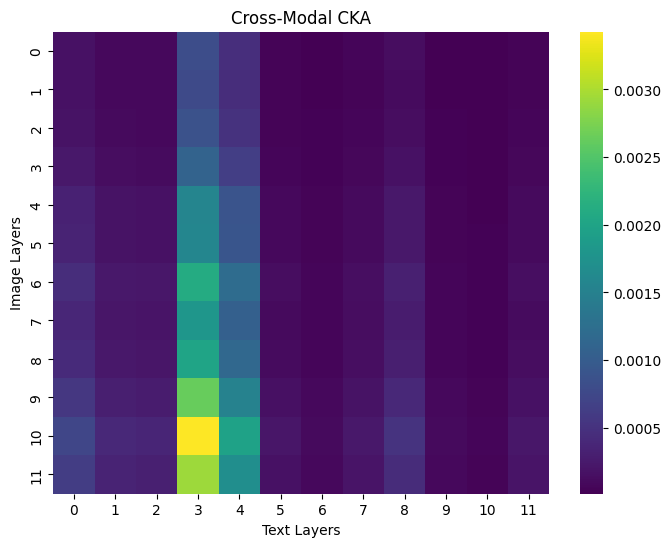

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(cka_matrix, cmap="viridis")
plt.xlabel("Text Layers")
plt.ylabel("Image Layers")
plt.title("Cross-Modal CKA")
plt.show()

## Generate cross-modal heatmap

100%|██████████| 12/12 [00:01<00:00,  8.94it/s]


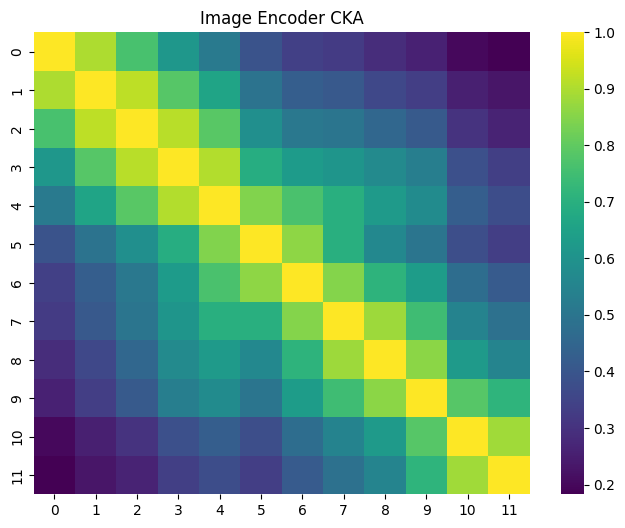

In [23]:
img_cka = np.zeros((num_layers, num_layers))

for i in tqdm(range(num_layers)):
    for j in range(num_layers):
        img_cka[i, j] = compute_cka(
            image_layer_outputs[i],
            image_layer_outputs[j]
        )

plt.figure(figsize=(8, 6))
sns.heatmap(img_cka, cmap="viridis")
plt.title("Image Encoder CKA")
plt.show()

100%|██████████| 12/12 [00:00<00:00, 21.80it/s]


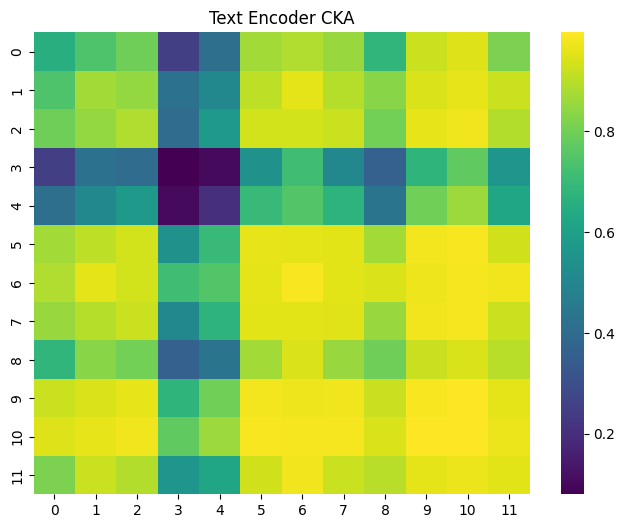

In [24]:
txt_cka = np.zeros((num_layers, num_layers))

for i in tqdm(range(num_layers)):
    for j in range(num_layers):
        txt_cka[i, j] = compute_cka(
            text_layer_outputs[i],
            text_layer_outputs[j]
        )

plt.figure(figsize=(8, 6))
sns.heatmap(txt_cka, cmap="viridis")
plt.title("Text Encoder CKA")
plt.show()

In [30]:
max_idx = np.unravel_index(np.argmax(cka_matrix), cka_matrix.shape)
print("Best alignment at:", max_idx)
print("CKA score:", cka_matrix[max_idx])

Best alignment at: (10, 3)
CKA score: 0.003426248356166706
